<a href="https://colab.research.google.com/github/atharvsalokhe30/Deep_Learning-_project_practice/blob/main/Diabetic_Prediction_(ANN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import the required python library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# load the dataset
data = pd.read_csv("pima-indians-diabetes.data.csv")

In [ ]:
# assign appropriate column name to dataset
column_names = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

data.columns = column_names

In [ ]:
# display the first five records
print(data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            1       85             66             29        0  26.6   
1            8      183             64              0        0  23.3   
2            1       89             66             23       94  28.1   
3            0      137             40             35      168  43.1   
4            5      116             74              0        0  25.6   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.351   31        0  
1                     0.672   32        1  
2                     0.167   21        0  
3                     2.288   33        1  
4                     0.201   30        0  


In [ ]:
# display the last five records
print(data.tail())

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
762           10      101             76             48      180  32.9   
763            2      122             70             27        0  36.8   
764            5      121             72             23      112  26.2   
765            1      126             60              0        0  30.1   
766            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
762                     0.171   63        0  
763                     0.340   27        0  
764                     0.245   30        0  
765                     0.349   47        1  
766                     0.315   23        0  


In [ ]:
# find the shape of the dataset
print("Shape of dataset:", data.shape)

Shape of dataset: (767, 9)


In [ ]:
# display the dataset information
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767 entries, 0 to 766
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               767 non-null    int64  
 1   Glucose                   767 non-null    int64  
 2   BloodPressure             767 non-null    int64  
 3   SkinThickness             767 non-null    int64  
 4   Insulin                   767 non-null    int64  
 5   BMI                       767 non-null    float64
 6   DiabetesPedigreeFunction  767 non-null    float64
 7   Age                       767 non-null    int64  
 8   Outcome                   767 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [ ]:
# generate the descriptive dataset
print(data.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   767.000000  767.000000     767.000000     767.000000  767.000000   
mean      3.842243  120.859192      69.101695      20.517601   79.903520   
std       3.370877   31.978468      19.368155      15.954059  115.283105   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   32.000000   
75%       6.000000  140.000000      80.000000      32.000000  127.500000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  767.000000                767.000000  767.000000  767.000000  
mean    31.990482                  0.471674   33.219035    0.348110  
std      7.889091                  0.331497   11.752296    0.476682  
min      0.000000                  

In [ ]:
#check missing value
print(data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
# check duplicate records
print("Duplicate Records:", data.duplicated().sum())

Duplicate Records: 0


In [ ]:
#Seprate input feature (x) and target variable (y)
x = data.drop("Outcome",axis=1)
y = data["Outcome"]

In [ ]:
# split dataset into training and testing
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
    )

In [ ]:
#apply feature scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
#build the ANN
model = Sequential()

model.add(Dense(units=16, activation='relu',input_dim=8))
model.add(Dense(units=8, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# compile the ANN
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Train the model
history = model.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=100,
    validation_split=0.2

)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4673 - loss: 0.7744 - val_accuracy: 0.4553 - val_loss: 0.7546
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5857 - loss: 0.6931 - val_accuracy: 0.5447 - val_loss: 0.6849
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6551 - loss: 0.6411 - val_accuracy: 0.6423 - val_loss: 0.6359
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6898 - loss: 0.6029 - val_accuracy: 0.6911 - val_loss: 0.6025
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7184 - loss: 0.5758 - val_accuracy: 0.6992 - val_loss: 0.5754
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7327 - loss: 0.5569 - val_accuracy: 0.7154 - val_loss: 0.5568
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7367 - loss: 0.5421 - val_accuracy: 0.7154 - val_loss: 0.5426
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7429 - loss: 0.5308 - val_accuracy: 0.7236 - 

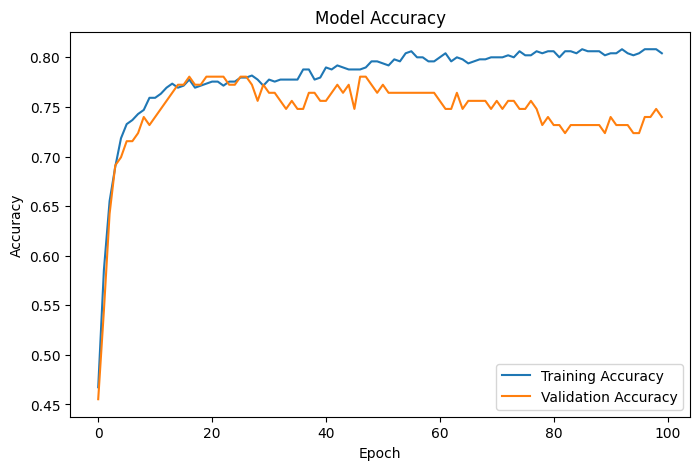

In [ ]:
# training accuracy graph
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

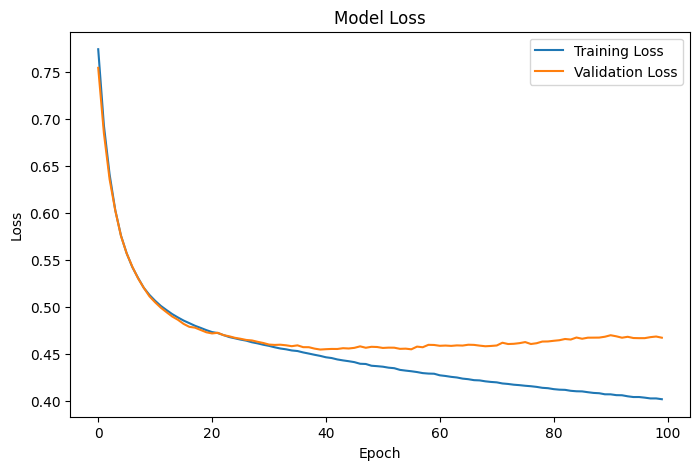

In [ ]:
# training loss graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# evaluate the model
loss, accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7727 - loss: 0.4825
Test Loss: 0.48248380422592163
Test Accuracy: 0.7727272510528564


In [ ]:
y_pred = model.predict(x_test)

y_pred = (y_pred > 0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [ ]:
# generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[82 15]
 [20 37]]


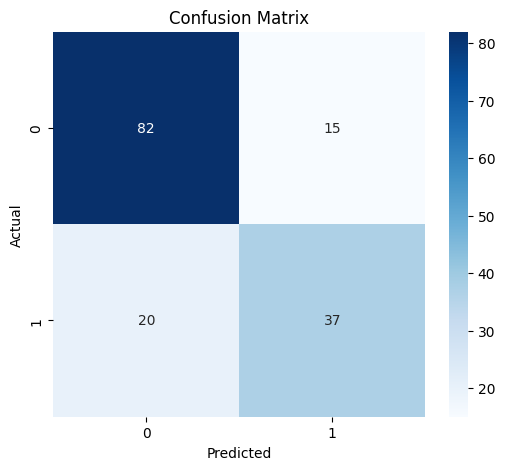

In [ ]:
#heat map
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            cmap='Blues',
            fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# generate the classification report

report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.80      0.85      0.82        97
           1       0.71      0.65      0.68        57

    accuracy                           0.77       154
   macro avg       0.76      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



In [ ]:
# calculate model accuracy
acc = accuracy_score(y_test, y_pred)

print("Accuracy =", acc*100)

Accuracy = 77.27272727272727


In [ ]:
new_patient = np.array([[2,120,70,20,85,28.5,0.45,35]])

new_patient = scaler.transform(new_patient)

prediction = model.predict(new_patient)

if prediction > 0.5:
    print("Patient is Diabetic")
else:
    print("Patient is Non-Diabetic")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Patient is Non-Diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
from tensorflow.keras.optimizers import Adam

# Compile the ANN model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
acc = accuracy_score(y_test, y_pred)

print("Accuracy =", acc*100)


Accuracy = 77.27272727272727


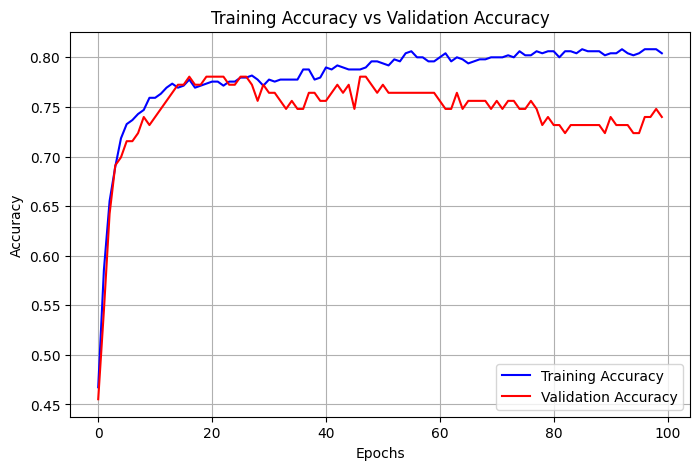

In [ ]:
import matplotlib.pyplot as plt

# Plot Training Accuracy and Validation Accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')

plt.title('Training Accuracy vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()